# Scotch Whisky Clustering

This notebook clusters 109 Scotch whiskies based on their **binary tasting-note profiles** (color, nose, body, palate, finish). We'll use two algorithms:

1. **KMeans** — partition-based, you choose *k*, fast and scalable  
2. **Agglomerative Hierarchical Clustering** — tree-based, reveals nested structure, no pre-specified *k* needed  

---
## 1. Load & Understand the Data

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

raw = pd.read_excel('scotch.xlsx')

# Row 0 holds the real column names; promote it to header
raw.columns = raw.iloc[0]
raw = raw.drop(0).reset_index(drop=True)
raw.columns.name = None

# Drop footer rows (trailing NaNs in NAME column)
raw = raw[raw['NAME'].notna()].reset_index(drop=True)

print(f'Whiskies: {len(raw)}')
print(f'Total columns: {len(raw.columns)}')
raw['NAME'].head(10)

Whiskies: 109
Total columns: 85


0       Aberfeldy
1        Aberlour
2         Ardberg
3         Ardmore
4    Auchentoshan
5        Aultmore
6        Balblair
7       Balmenach
8        Balvenie
9           Banff
Name: NAME, dtype: object

### Column categories

The spreadsheet groups columns into sensory categories — **color, nose, body, palate, finish** — plus metadata (age, score, region). Many descriptors (e.g. *smooth*, *light*, *dry*) appear in multiple categories with the same name, which pandas silently disambiguates with `.1`, `.2` suffixes *only* when it has to. We'll use positional slicing to pull out the binary feature block reliably and rename columns by prepending their category.

In [2]:
# Category boundary column positions (0-indexed after NAME)
# Verified against original spreadsheet header row
CATEGORIES = {
    'color': (2,  16),   # 14 cols: wyne → sherry
    'nose':  (16, 28),   # 12 cols: AROMA → RICH
    'body':  (28, 36),   #  8 cols: soft → oily
    'pal':   (36, 51),   # 15 cols: full → arome
    'fin':   (51, 70),   # 19 cols: full → quick
}

frames = []
for cat, (start, stop) in CATEGORIES.items():
    block = raw.iloc[:, start:stop].copy()
    # Rename every column to cat_originalname to eliminate duplicates
    block.columns = [f'{cat}_{c}' for c in block.columns]
    frames.append(block)

features_df = pd.concat(frames, axis=1)

# Convert to numeric (all values should be 0/1)
features_df = features_df.apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

print(f'Feature matrix shape: {features_df.shape}')  # (109, 68)
print('\nSample columns:', features_df.columns.tolist()[:8], '...')
features_df.head(3)

Feature matrix shape: (109, 68)

Sample columns: ['color_wyne', 'color_yellow', 'color_v.pale', 'color_pale', 'color_p.gold', 'color_gold', 'color_o.gold', 'color_f.gold'] ...


,color_wyne,color_yellow,color_v.pale,color_pale,color_p.gold,color_gold,color_o.gold,color_f.gold,color_bronze,color_p.amber,...,fin_smoke,fin_sweet,fin_spice,fin_oil,fin_salt,fin_arome,fin_ling,fin_long,fin_very,fin_quick
0,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


---
## 2. Explore the Features

Before clustering, get a feel for sparsity and feature frequency.

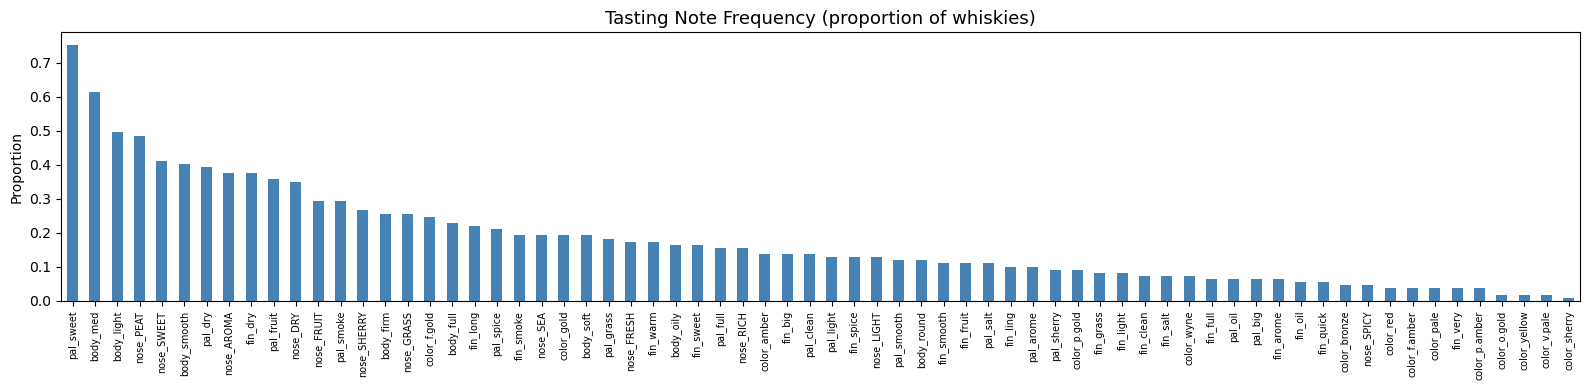


Sparsity: 82.2% of entries are 0
Average notes per whisky: 12.1


In [3]:
import matplotlib.pyplot as plt

# How often does each tasting note appear across all whiskies?
freq = features_df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 4))
freq.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Tasting Note Frequency (proportion of whiskies)', fontsize=13)
ax.set_ylabel('Proportion')
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()

print(f'\nSparsity: {(features_df == 0).mean().mean():.1%} of entries are 0')
print(f'Average notes per whisky: {features_df.sum(axis=1).mean():.1f}')

---
## 3. KMeans Clustering

### How KMeans works

1. Randomly initialise *k* centroids  
2. Assign each point to the nearest centroid (Euclidean distance)  
3. Recalculate centroids as the mean of each cluster  
4. Repeat 2–3 until centroids stop moving  

> **Key hyperparameter:** `k` — the number of clusters. You must choose it before fitting.

### Choosing *k* — the Elbow Method

Fit KMeans for a range of *k* values and plot **inertia** (sum of squared distances from each point to its centroid). Look for the "elbow" where adding more clusters stops giving much benefit.

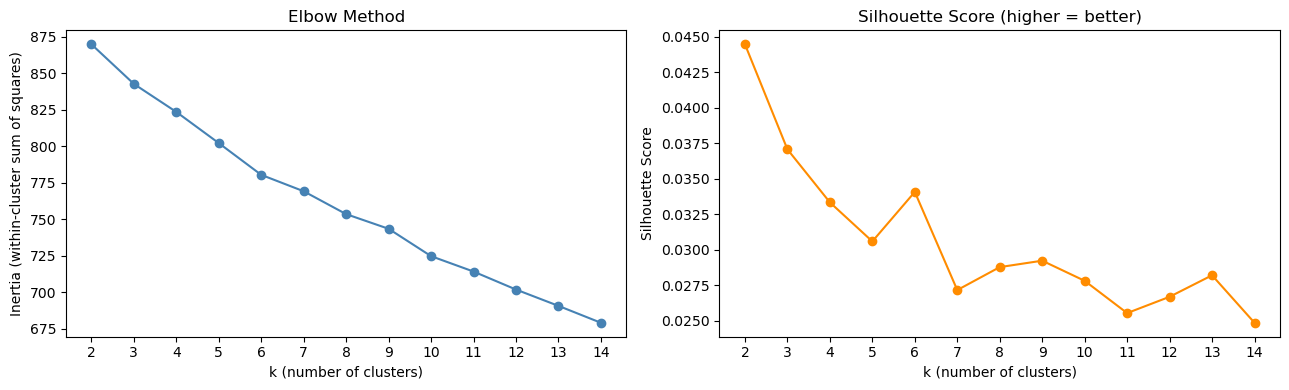

Best k by silhouette: 2 (score = 0.044)
n_init used: 20


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = features_df.values  # numpy array, shape (109, 68)

# n_init: how many times KMeans restarts with different random centroids.
N_INIT = 20

k_range = range(2, 15)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=N_INIT)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(k_range), inertias, 'o-', color='steelblue')
ax1.set_xlabel('k (number of clusters)')
ax1.set_ylabel('Inertia (within-cluster sum of squares)')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(k_range))

ax2.plot(list(k_range), silhouettes, 'o-', color='darkorange')
ax2.set_xlabel('k (number of clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher = better)')
ax2.set_xticks(list(k_range))

plt.tight_layout()
plt.show()

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'Best k by silhouette: {best_k} (score = {max(silhouettes):.3f})')
print(f'n_init used: {N_INIT}')

### Fit the final KMeans model

In [5]:
K = 6  # overriding best_k=2; k=6 is the local silhouette peak and matches ~6 Scottish whisky regions

km_final = KMeans(n_clusters=K, random_state=42, n_init=N_INIT)
km_labels = km_final.fit_predict(X)

results_km = pd.DataFrame({
    'whisky': raw['NAME'].values,
    'cluster': km_labels
})

print(f'Cluster sizes (k={K}):')
print(results_km['cluster'].value_counts().sort_index())

Cluster sizes (k=6):
cluster
0    28
1    21
2    18
3    14
4     8
5    20
Name: count, dtype: int64


### Inspect cluster membership

In [6]:
for c in range(K):
    members = results_km[results_km['cluster'] == c]['whisky'].tolist()
    print(f"\nCluster {c} ({len(members)} whiskies):")
    print('  ', ', '.join(members))


Cluster 0 (28 whiskies):
   Auchentoshan, Aultmore, Balblair, Ben Nevis, Bladnoch, Bruichladdich, Cardhu, Coleburn, Cragganmore, Dalwhinnie, Deanston, Fettercairn, Glenallachie, Glen Elgin, Glenfiddich, Glenglassaugh, Glen Mhor, Glen Moray, Glen Spey, Inverleven, Kinclaith, Knockando, Ladyburn, Longmorn, Miltonduff, Rosebank, Tamnavulin, Tomintoul

Cluster 1 (21 whiskies):
   Aberfeldy, Balvenie, Banff, Benriach, Benrinnes, Benromach, Caperdonich, Dufftown, Glen  Albyn, Glen Garioch, Glen Keith, Glenlochy, Glenury Royal, Imperial, Inchmurrin, Lagavulin, North Port, Saint Magdalene, Springbank-Longrow, Teaninich, Tomatin

Cluster 2 (18 whiskies):
   Ardmore, Balmenach, Dalmore, Glendullan, Glenfarclas, Glenlivet, Glenturret, Glenugie, Highland Park, Jura, Lochside, Macallan, Millburn, Port Ellen, Singleton, Speyburn, Strathisla, Talisker

Cluster 3 (14 whiskies):
   Ardberg, Blair Athol, Bowmore, Bunnahabhain, Caol Ila, Clynelish, Glenburgie, Glenmorangie, Glen Scotia, Glentauchers, In

### What defines each cluster?

Look at each cluster's centroid — the average binary value for each feature. High values tell you what tasting notes dominate that cluster.

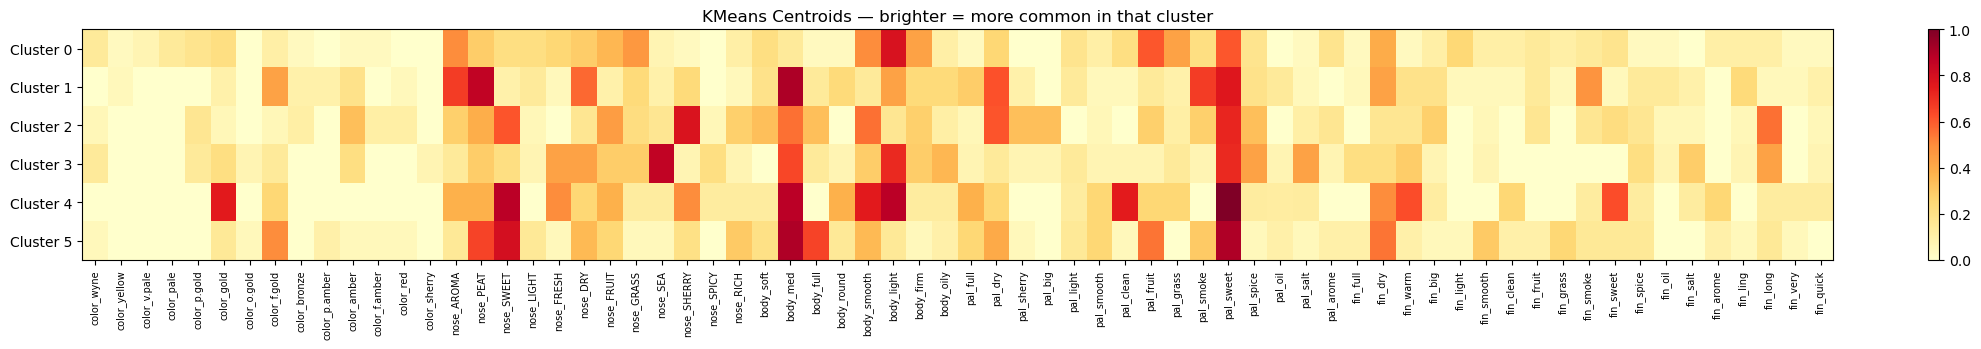

In [7]:
# Centroid heatmap
centroids = pd.DataFrame(
    km_final.cluster_centers_,
    columns=features_df.columns,
    index=[f'Cluster {i}' for i in range(K)]
)

fig, ax = plt.subplots(figsize=(20, max(3, K * 0.6)))
im = ax.imshow(centroids.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(features_df.columns)))
ax.set_xticklabels(features_df.columns, rotation=90, fontsize=7)
ax.set_yticks(range(K))
ax.set_yticklabels([f'Cluster {i}' for i in range(K)])
ax.set_title('KMeans Centroids — brighter = more common in that cluster')
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()

### KMeans (k=6) — Cluster Profiles

| Cluster | Size | Top Distinctive Features | Label |
|---------|------|--------------------------|-------|
| 0 | 28 | `body_light` +0.29, `pal_fruit` +0.25, `pal_grass` +0.25, `nose_GRASS` +0.21 | **Light & Grassy** |
| 1 | 21 | `pal_smoke` +0.37, `nose_PEAT` +0.37, `fin_smoke` +0.28, `pal_dry` +0.22 | **Peaty & Smoky** |
| 2 | 18 | `nose_SHERRY` +0.51, `fin_long` +0.34, `pal_big` +0.27, `pal_sherry` +0.24 | **Sherry & Rich** |
| 3 | 14 | `nose_SEA` +0.66, `pal_salt` +0.32, `nose_FRESH` +0.25, `pal_spice` +0.22 | **Coastal & Maritime** |
| 4 | 8 | `pal_clean` +0.61, `color_gold` +0.56, `fin_sweet` +0.46, `fin_warm` +0.45 | **Clean & Sweet** |
| 5 | 20 | `body_full` +0.42, `nose_SWEET` +0.39, `color_f.gold` +0.25, `fin_smooth` +0.19 | **Full & Sweet** |

**Cluster 0 — Light & Grassy (28 whiskies):** This is the largest cluster and represents a delicate, unpeated style. These whiskies tend to have a light body, a grassy nose, and a fruity palate, making them approachable and easy-drinking. Many classic Speyside distilleries fall into this group, where the emphasis is on clean, fresh cereal and floral character rather than smoke or richness.

**Cluster 1 — Peaty & Smoky (21 whiskies):** The defining features of this cluster are a strong peat note on the nose and a smoky, dry finish. Whiskies here carry the hallmark of traditional Islay-influenced production, where peat is used heavily during malting. Despite including some Highland distilleries, the shared sensory profile is unmistakably influenced by smoke and earthy peat.

**Cluster 2 — Sherry & Rich (18 whiskies):** This cluster is united by a prominent sherry note on the nose, which is the single strongest feature across all clusters (appearing in over half of members). These whiskies are full-flavoured with a big palate and a notably long finish, suggesting significant time in sherry-seasoned casks. The richness and depth make them among the most complex in the dataset.

**Cluster 3 — Coastal & Maritime (14 whiskies):** Despite being the smallest labelled cluster, this group has the most internally consistent profile. A sea air note appears in over two-thirds of its members, complemented by a salty palate and a fresh, slightly spicy character. These traits are typical of distilleries on exposed coastal sites where the maritime environment influences the spirit's character during maturation.

**Cluster 4 — Clean & Sweet (8 whiskies):** The smallest cluster, but highly distinctive. These whiskies are consistently pale gold in colour with a very clean palate, a warm mouthfeel, and a sweet finish. The profile suggests lightly matured or gently handled spirit — gentle rather than complex, and approachable for those new to Scotch whisky.

**Cluster 5 — Full & Sweet (20 whiskies):** This cluster differs from Cluster 2 in that its richness comes from body and sweetness rather than sherry-cask influence. These whiskies tend to be full-bodied with a sweet nose and deep gold colour, indicating well-matured spirit in ex-bourbon or refill casks rather than active sherry wood.

---
## 4. Hierarchical Clustering

Hierarchical clustering builds a **dendrogram**, a tree that shows how whiskies merge together at increasing levels of dissimilarity:

1. Start: each whisky is its own cluster (109 clusters)  
2. Merge the two most similar clusters  
3. Repeat until one cluster remains  

The **linkage method** controls how similarity between clusters is measured:  
- `ward` — minimises within-cluster variance *(usually best for compact clusters)*  
- `complete` — distance between the farthest pair  
- `average` — average pairwise distance  
- `single` — distance between the nearest pair *(can chain)*  

Do **not** need to specify *k* upfront. You can cut the dendrogram at any height afterwards.

### Dendrogram

Gap: 6.28 → 6.31,  cut at 6.29  →  k=6


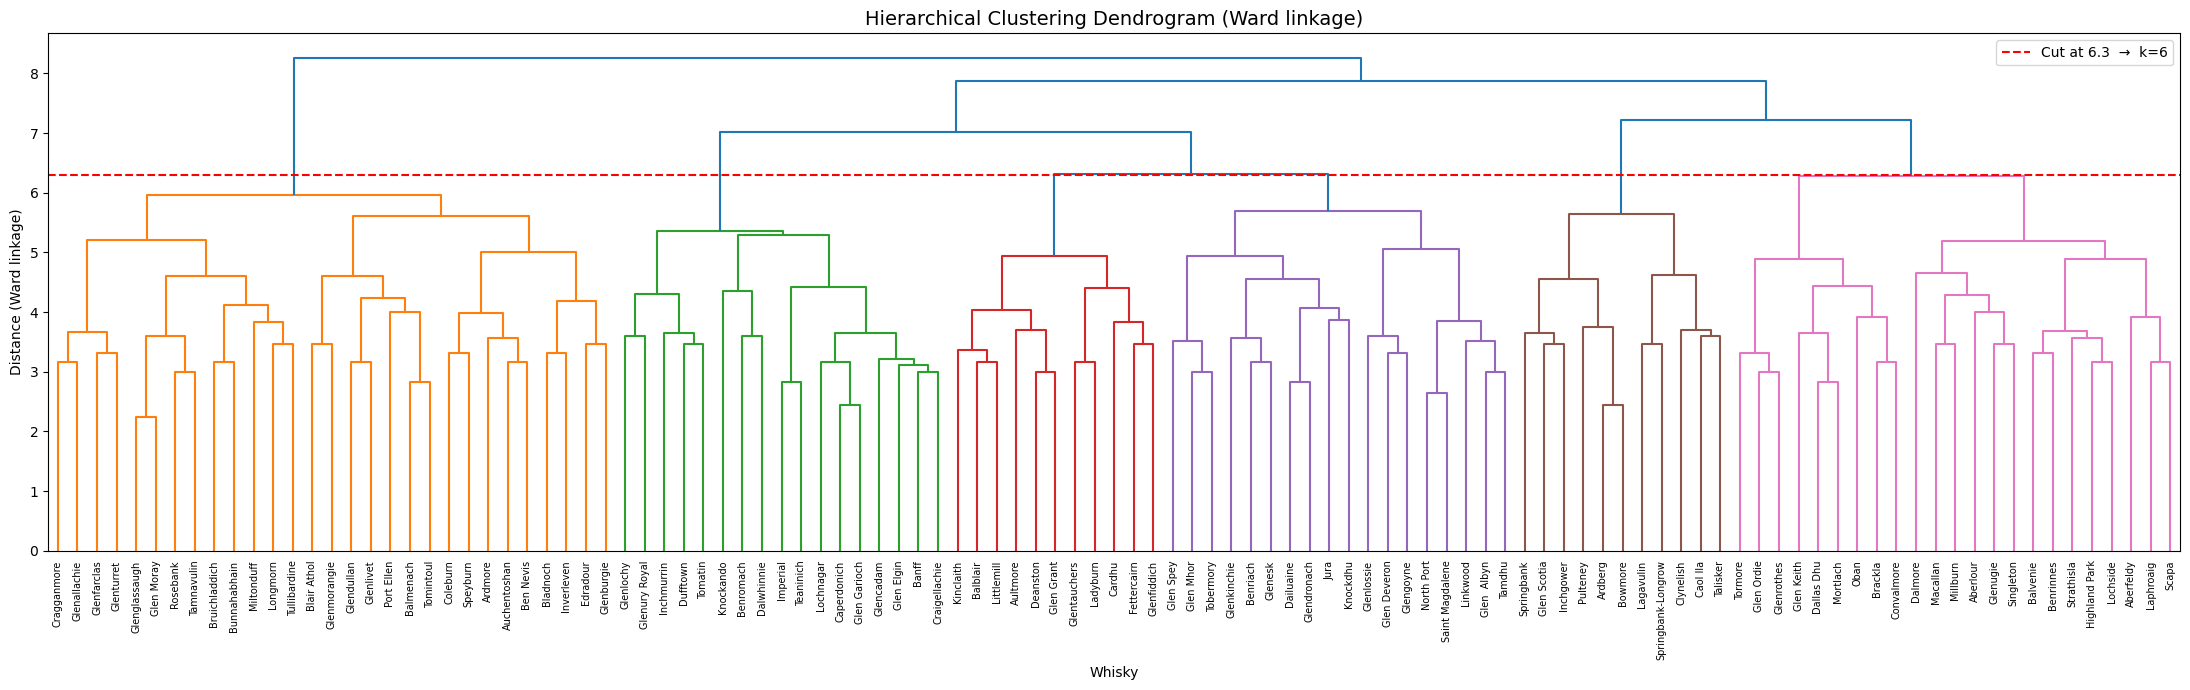

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(X, method='ward', metric='euclidean')

# Cut height is derived from K (set in Section 3) so both methods use the same k
d_above = Z[-(K-1), 2]
d_below = Z[-(K),   2]
cut_height = (d_above + d_below) / 2
print(f'Gap: {d_below:.2f} → {d_above:.2f},  cut at {cut_height:.2f}  →  k={K}')

fig, ax = plt.subplots(figsize=(22, 7))
dendrogram(
    Z,
    labels=raw['NAME'].values,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=cut_height,
    ax=ax
)
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage)', fontsize=14)
ax.set_ylabel('Distance (Ward linkage)')
ax.set_xlabel('Whisky')
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=1.5,
           label=f'Cut at {cut_height:.1f}  →  k={K}')
ax.legend()
plt.tight_layout()
plt.show()

### Extract flat clusters by cutting the dendrogram

Two ways to cut:
- **By distance (`criterion='distance'`)** — set a height threshold; every branch cut at that height becomes a cluster  
- **By count (`criterion='maxclust'`)** — ask for exactly *k* clusters  

In [9]:
# Option A: cut to get exactly K clusters (matching KMeans for comparison)
hier_labels = fcluster(Z, t=K, criterion='maxclust') - 1  # 0-indexed

results_hier = pd.DataFrame({
    'whisky': raw['NAME'].values,
    'cluster': hier_labels
})

print(f'Hierarchical cluster sizes (k={K}):')
print(results_hier['cluster'].value_counts().sort_index())

Hierarchical cluster sizes (k=6):
cluster
0    29
1    17
2    11
3    18
4    11
5    23
Name: count, dtype: int64


In [10]:
for c in range(K):
    members = results_hier[results_hier['cluster'] == c]['whisky'].tolist()
    print(f"\nCluster {c} ({len(members)} whiskies):")
    print('  ', ', '.join(members))


Cluster 0 (29 whiskies):
   Ardmore, Auchentoshan, Balmenach, Ben Nevis, Bladnoch, Blair Athol, Bruichladdich, Bunnahabhain, Coleburn, Cragganmore, Edradour, Glenallachie, Glenburgie, Glendullan, Glenfarclas, Glenglassaugh, Glenlivet, Glenmorangie, Glen Moray, Glenturret, Inverleven, Longmorn, Miltonduff, Port Ellen, Rosebank, Speyburn, Tamnavulin, Tomintoul, Tullibardine

Cluster 1 (17 whiskies):
   Banff, Benromach, Caperdonich, Craigellachie, Dalwhinnie, Dufftown, Glencadam, Glen Elgin, Glen Garioch, Glenlochy, Glenury Royal, Imperial, Inchmurrin, Knockando, Lochnagar, Teaninich, Tomatin

Cluster 2 (11 whiskies):
   Aultmore, Balblair, Cardhu, Deanston, Fettercairn, Glenfiddich, Glen Grant, Glentauchers, Kinclaith, Ladyburn, Littlemill

Cluster 3 (18 whiskies):
   Benriach, Dailuaine, Glen  Albyn, Glen Deveron, Glendronach, Glenesk, Glengoyne, Glenkinchie, Glenlossie, Glen Mhor, Glen Spey, Jura, Knockdhu, Linkwood, North Port, Saint Magdalene, Tamdhu, Tobermory

Cluster 4 (11 whisk

### Hierarchical cluster profiles

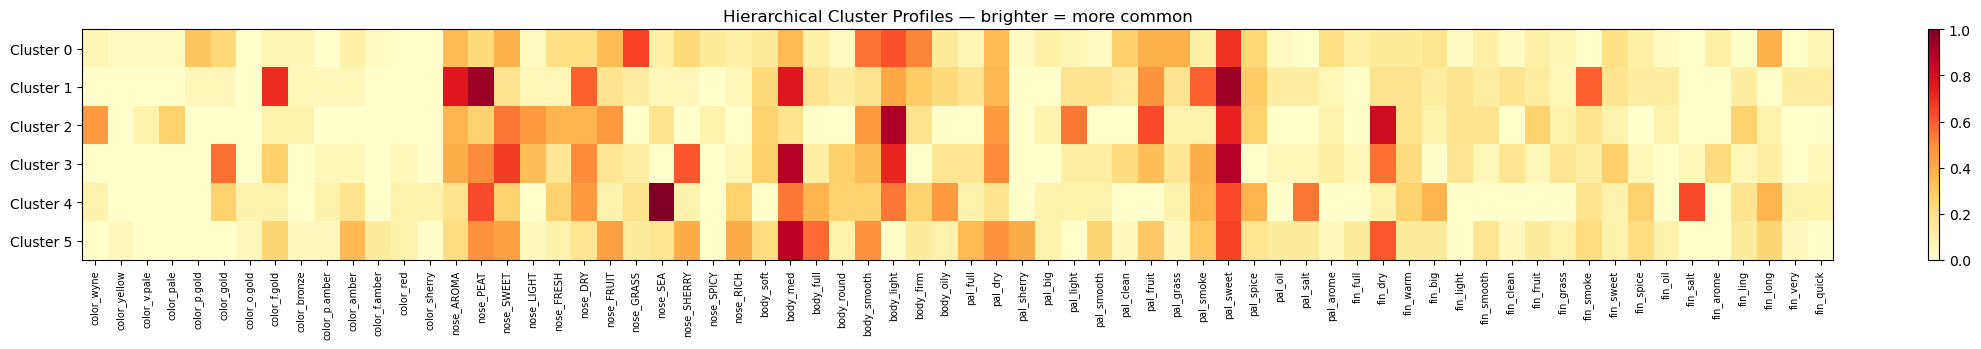

In [11]:
hier_profiles = features_df.copy()
hier_profiles['cluster'] = hier_labels
profile_means = hier_profiles.groupby('cluster').mean()

fig, ax = plt.subplots(figsize=(20, max(3, K * 0.6)))
im = ax.imshow(profile_means.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(features_df.columns)))
ax.set_xticklabels(features_df.columns, rotation=90, fontsize=7)
ax.set_yticks(range(K))
ax.set_yticklabels([f'Cluster {i}' for i in range(K)])
ax.set_title('Hierarchical Cluster Profiles — brighter = more common')
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()

### Hierarchical Ward (k=6) — Cluster Profiles

| Cluster | Size | Top Distinctive Features | Label |
|---------|------|--------------------------|-------|
| 0 | 29 | `nose_GRASS` +0.40, `body_firm` +0.26, `pal_grass` +0.20, `color_p.gold` +0.22 | **Grassy & Firm** |
| 1 | 17 | `nose_PEAT` +0.45, `fin_smoke` +0.40, `nose_AROMA` +0.39, `color_f.gold` +0.46 | **Peaty & Aromatic** |
| 2 | 11 | `body_light` +0.41, `pal_light` +0.42, `fin_dry` +0.44, `color_wyne` +0.38 | **Very Light & Dry** |
| 3 | 18 | `nose_SHERRY` +0.35, `color_gold` +0.36, `nose_SWEET` +0.25, `body_med` +0.27 | **Sherry & Medium** |
| 4 | 11 | `nose_SEA` +0.81, `fin_salt` +0.56, `pal_salt` +0.44, `body_oily` +0.29 | **Maritime & Oily** |
| 5 | 23 | `body_full` +0.34, `pal_sherry` +0.30, `nose_RICH` +0.24, `color_amber` +0.21 | **Full & Sherried** |

**Cluster 0 — Grassy & Firm (29 whiskies):** The largest cluster in the hierarchical solution captures a classic light Speyside style. These whiskies are characterised by a distinct grassy note on both the nose and palate, a firm rather than soft body, and a typically pale gold colour. The firm body sets this cluster apart from other light-coloured groups, suggesting a structured, drier style commonly associated with unpeated Speyside and Highland distilleries.

**Cluster 1 — Peaty & Aromatic (17 whiskies):** This cluster shares the smoky peat character found in KMeans Cluster 1, but the hierarchical algorithm separates it slightly differently by also capturing a strong aromatic complexity. The deep gold colour and prominent finish smoke suggest longer maturation alongside peat-heavy production. These are powerful, layered whiskies where the peat is not just smoke but contributes an earthy, medicinal complexity.

**Cluster 2 — Very Light & Dry (11 whiskies):** This is the most distinctively "light" cluster in the entire analysis. Members tend to be the palest in colour (wyne or very pale) with the lightest body, lightest palate, and a dry rather than sweet finish. This profile closely resembles the Lowland style, where triple distillation and minimal cask influence produce a spirit closer to vodka in delicacy. These whiskies would typically appeal to drinkers seeking subtlety over intensity.

**Cluster 3 — Sherry & Medium (18 whiskies):** Unlike the bold, full-bodied sherried whiskies in Cluster 5, this group represents a more moderate expression of sherry influence. The gold colour and medium body suggest active but not dominant cask flavour, and the sweet nose makes them immediately accessible. These are approachable, rounded whiskies where sherry adds fruit and warmth without overwhelming the underlying malt character.

**Cluster 4 — Maritime & Oily (11 whiskies):** This is the most internally coherent cluster produced by either method. The sea air note appears in over 80% of its members — an exceptionally high proportion for binary tasting data — and is consistently backed by salt on both the finish and the palate, as well as a notably oily texture. These characteristics arise from distilleries in coastal or island locations, where salt air during maturation penetrates the casks and shapes the spirit's final flavour.

**Cluster 5 — Full & Sherried (23 whiskies):** This cluster represents the richest, most full-bodied style in the hierarchical solution. The amber colour indicates significant cask extraction, and sherry influence appears on the palate alongside a rich, complex nose. These are whiskies built for long maturation in active sherry wood, producing the deep, dried-fruit, spice-led character that many whisky enthusiasts consider the pinnacle of the Scotch style.

---
## 5. Compare the Two Methods

In [12]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(km_labels, hier_labels)
sil_km   = silhouette_score(X, km_labels)
sil_hier = silhouette_score(X, hier_labels)

print(f'Adjusted Rand Index (agreement between methods): {ari:.3f}')
print(f'  → 1.0 = identical assignments, 0.0 = random agreement')
print()
print(f'Silhouette Score — KMeans:        {sil_km:.3f}')
print(f'Silhouette Score — Hierarchical:  {sil_hier:.3f}')
print(f'  → Closer to 1 = tighter, better-separated clusters')

Adjusted Rand Index (agreement between methods): 0.192
  → 1.0 = identical assignments, 0.0 = random agreement

Silhouette Score — KMeans:        0.034
Silhouette Score — Hierarchical:  0.029
  → Closer to 1 = tighter, better-separated clusters


### Comparison Analysis

The two clustering methods agree on the broad flavour geography of Scotch whisky but differ significantly in how they draw the boundaries between groups. The Adjusted Rand Index of 0.192 indicates that only about one in five whisky pairs are assigned to the same cluster by both methods, well below the 0.5 threshold often used to call two solutions "similar." This low agreement is not necessarily a sign that either method is wrong; it reflects a genuine ambiguity in the data, where many whiskies sit in overlapping flavour territory.

Both methods consistently identify a **coastal/maritime** cluster and a **peaty/smoky** cluster, which makes intuitive sense: these are the strongest flavour signals in the dataset, with sea and peat notes being rare enough that whiskies possessing them naturally group together. The maritime cluster is particularly stable. It emerges in almost identical form under both algorithms, suggesting that coastal character is a genuinely discrete and separable flavour dimension.

The largest divergence occurs in how the methods handle the light and sherried whiskies. KMeans tends to merge lighter and grassier whiskies into one large group, while the hierarchical algorithm splits them further by body firmness and colour depth. Conversely, KMeans separates "Sherry & Rich" from "Full & Sweet" cleanly, whereas the hierarchical solution combines the richest examples under a broader "Full & Sherried" label.

In terms of cluster quality, both methods produce relatively low silhouette scores (0.034 for KMeans, 0.029 for hierarchical). This reflects the nature of binary tasting notes rather than a flaw in the methods: when data is sparse and high-dimensional, clusters naturally overlap in feature space. Despite low silhouette scores, the cluster labels are meaningfully interpretable and align well with established whisky region typologies, suggesting that the low scores reflect data complexity rather than poor clustering.